# Poisson Parameter Estimation via Maximum Likelihood

Estimating the arrival rate of a Poisson process using Maximum Likelihood Estimation. Walks through likelihood construction, visual optimization, and how observation length affects estimation precision. Implemented in R with ggplot2 visualizations.

## Setup and Overview


### Setup

In [18]:
set.seed(7)

lambda_true <- 6  # hidden truth for simulation (customers/hour)

### Section 1: One observed sample

In [19]:
# Generate one 24-hour sample of hourly counts (x_obs) and report its sample mean.

x_obs <- rpois(n = 24, lambda = lambda_true)

sample_mean <- mean(x_obs)
print(x_obs)
cat("\nSample mean:", sample_mean, "\n")


 [1]  4  8  5 11  4  6  4  4  8  3  6  3  6  1 12  5  7  5 14  9 12  3  7  6

Sample mean: 6.375 


### Section 2: Maximum Likelihood (ML) as a curve

Instead of formulas, we'll try many λ values and compute how plausible the observed data looks under each λ. The best λ is at the peak (maximum likelihood).

Warning message in geom_point(aes(x = ml_estimate, y = max(log_likelihood)), color = "red", :
"All aesthetics have length 1, but the data has 150 rows.
ℹ Please consider using `annotate()` or provide this layer with data containing
  a single row."


ML estimate (from curve): 6.4 
Sample mean: 6.375 


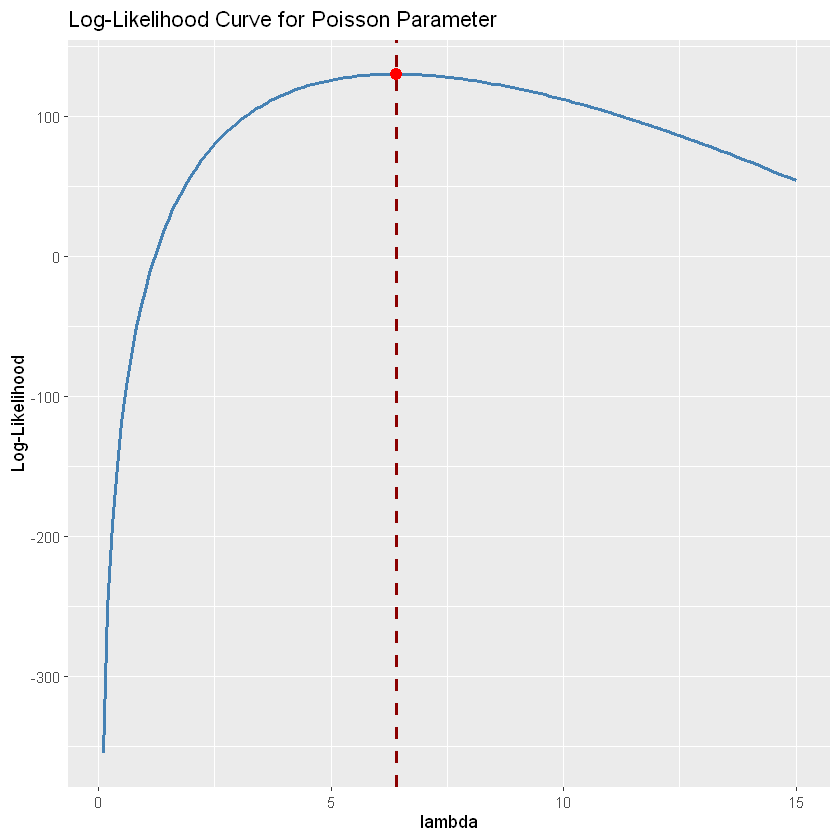

In [28]:
# 1) Try λ values from 0.1 to 15 (with a small step) and compute how well the observed data fits each λ (log-likelihood).
# 2) Plot log-likelihood versus λ and find the λ where the curve reaches its maximum (this is the ML estimate).
# 3) Mark the sample mean on the same plot and write one sentence about whether it is close to the ML estimate.
lambda_vals <- seq(0.1, 15, by = 0.1)

log_likelihood <- sapply(lambda_vals, function(lambda) {
  sum(x_obs * log(lambda) - lambda)
})

ml_estimate_idx <- which.max(log_likelihood)
ml_estimate <- lambda_vals[ml_estimate_idx]

likelihood_df <- data.frame(
  lambda = lambda_vals,
  log_likelihood = log_likelihood
)

p <- ggplot(likelihood_df, aes(x = lambda, y = log_likelihood)) +
  geom_line(color = "steelblue", linewidth = 1) +
  geom_vline(xintercept = ml_estimate, color = "darkred", linetype = "dashed", linewidth = 1) +
  geom_point(aes(x = ml_estimate, y = max(log_likelihood)), color = "red", size = 3) +
  labs(
    title = "Log-Likelihood Curve for Poisson Parameter",
    x = "lambda", y = "Log-Likelihood") 
print(p)

cat("ML estimate (from curve):", ml_estimate, "\n")
cat("Sample mean:", sample_mean, "\n")

### Section 3: ML estimate from the sample

For Poisson, the ML estimate equals the sample mean (your curve should peak right there).

In [30]:
# Compute the ML estimate of λ directly from the observed sample, and report the estimated "average events per hour" as a single number.

lambda_hat <- mean(x_obs)

cat("Estimated average number of customers per hour:", lambda_hat, "\n")

Estimated average number of customers per hour: 6.375 


### Section 4: What happens when we observe more hours?

Now we simulate repeated data collection. For each observation length, we repeat B = 1000 times to see the distribution of the estimate.

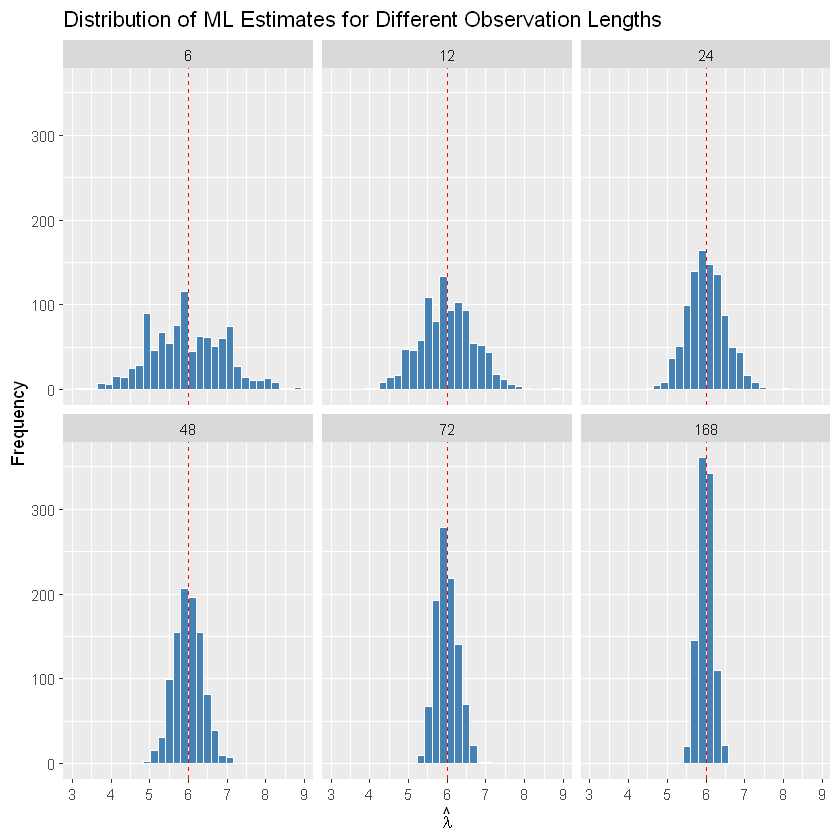

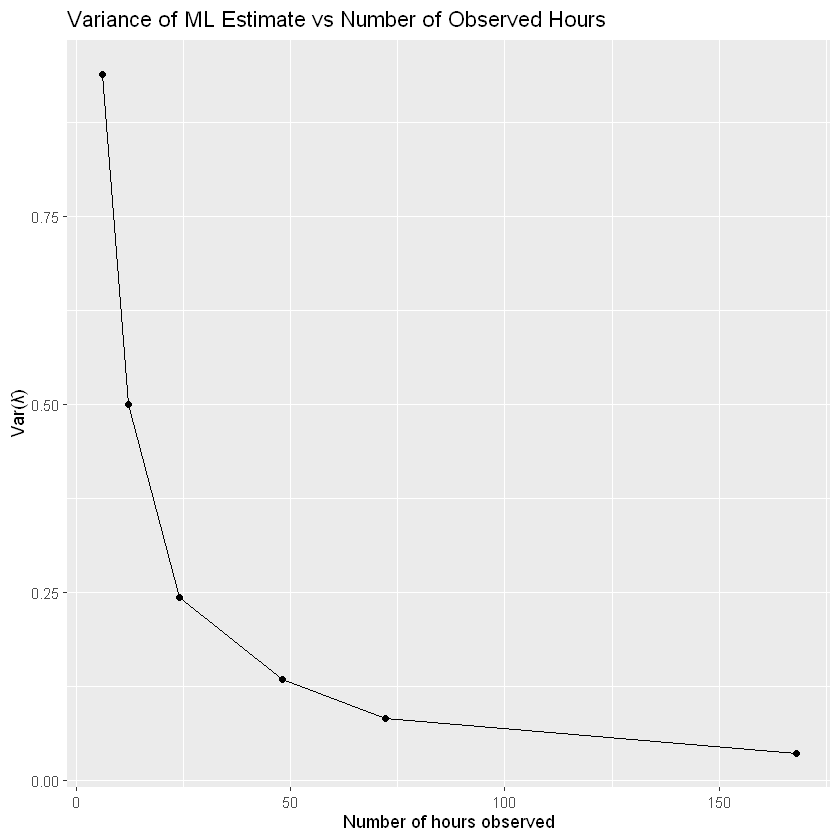

In [ ]:
# 1) Pick several observation lengths (from a few hours up to many days).
# 2) For each length, repeat the experiment 1000 times: generate hourly counts and compute one λ estimate each time.
# 3) Store all estimates so you can compare how "spread out" the estimates are for short vs long observation periods.
B <- 1000
sample_sizes <- c(6, 12, 24, 48, 72, 168) 
results <- data.frame()

for (n in sample_sizes) {
  estimates <- replicate(B, {
    mean(rpois(n, lambda_true))
  })
  
  results <- rbind(
    results,
    data.frame(
      n = n,
      lambda_hat = estimates
    )
  )
}

ggplot(results, aes(x = lambda_hat)) +
  geom_histogram(bins = 30, fill = "steelblue", color = "white") +
  facet_wrap(~ n) +
  geom_vline(xintercept = lambda_true, linetype = "dashed", color = "red") +
  labs(
    title = "Distribution of ML Estimates for Different Observation Lengths",
    x = expression(hat(lambda)),
    y = "Frequency"
  )
  variance_summary <- aggregate(lambda_hat ~ n, results, var)
ggplot(variance_summary, aes(x = n, y = lambda_hat)) +
  geom_line() +
  geom_point() +
  labs(
    title = "Variance of ML Estimate vs Number of Observed Hours",
    x = "Number of hours observed",
    y = "Variance"
  )



Average of λ estimates: 6.03275 
Standard deviation of λ estimates: 1.25317 


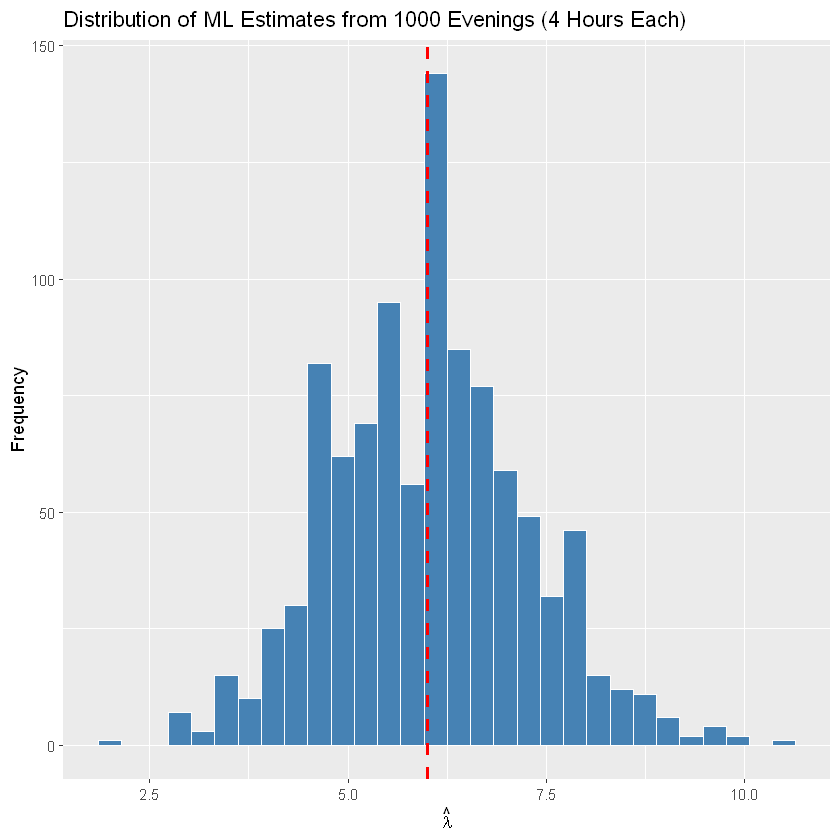

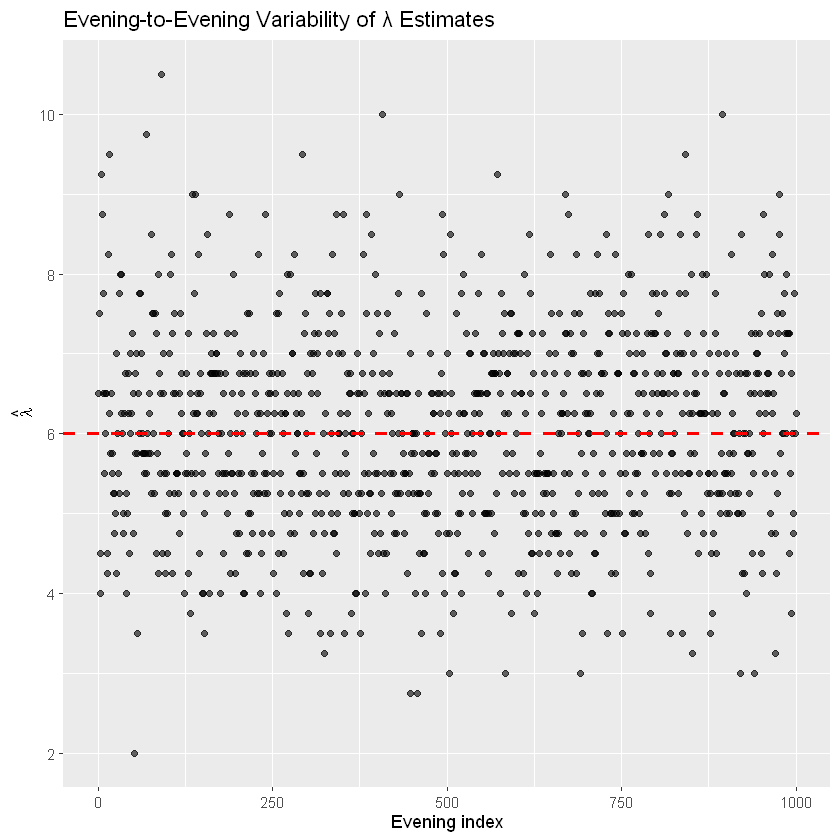

In [38]:
# Simulate 1000 different evenings (4 hours each). For each evening, estimate λ from the 4 hourly counts.
# Then visualize how much the estimate changes from evening to evening (histogram + scatter plot),
# and report the average and standard deviation of these 1000 estimates. Mark the true λ on the plots.
lambda_true <- 6
B <- 1000
hours <- 4

lambda_hats <- replicate(B, {
  mean(rpois(hours, lambda_true))
})

mean_hat <- mean(lambda_hats)
sd_hat <- sd(lambda_hats)

cat("Average of λ estimates:", mean_hat, "\n")
cat("Standard deviation of λ estimates:", sd_hat, "\n")

df <- data.frame(
  evening = 1:B,
  lambda_hat = lambda_hats
)

ggplot(df, aes(x = lambda_hat)) +
  geom_histogram(bins = 30, fill = "steelblue", color = "white") +
  geom_vline(xintercept = lambda_true, color = "red",
             linetype = "dashed", linewidth = 1) +
  labs(
    title = "Distribution of ML Estimates from 1000 Evenings (4 Hours Each)",
    x = expression(hat(lambda)),
    y = "Frequency"
  )
  ggplot(df, aes(x = evening, y = lambda_hat)) +
  geom_point(alpha = 0.6) +
  geom_hline(yintercept = lambda_true, color = "red",
             linetype = "dashed", linewidth = 1) +
  labs(
    title = "Evening-to-Evening Variability of λ Estimates",
    x = "Evening index",
    y = expression(hat(lambda))
  )



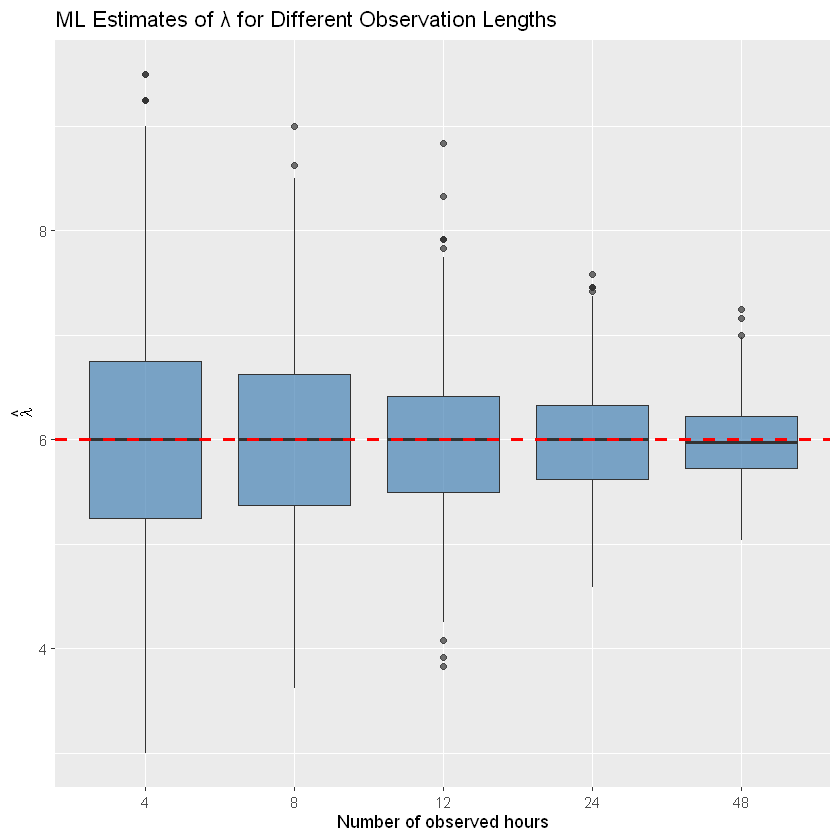

In [39]:
# Compare the λ estimates across different observation lengths by plotting them side-by-side.
# Use a boxplot (one box per observation length) to see how the spread shrinks as you observe more hours.
# Add a horizontal reference line for the true λ and write one sentence describing what changes as length increases.
lambda_true <- 6
B <- 1000
observation_lengths <- c(4, 8, 12, 24, 48)
results <- data.frame()

for (n in observation_lengths) {
  lambda_hats <- replicate(B, {
    mean(rpois(n, lambda_true))
  })
  
  results <- rbind(
    results,
    data.frame(
      hours = factor(n),
      lambda_hat = lambda_hats
    )
  )
}

ggplot(results, aes(x = hours, y = lambda_hat)) +
  geom_boxplot(fill = "steelblue", alpha = 0.7) +
  geom_hline(yintercept = lambda_true, color = "red",
             linetype = "dashed", linewidth = 1) +
  labs(
    title = "ML Estimates of λ for Different Observation Lengths",
    x = "Number of observed hours",
    y = expression(hat(lambda))
  )


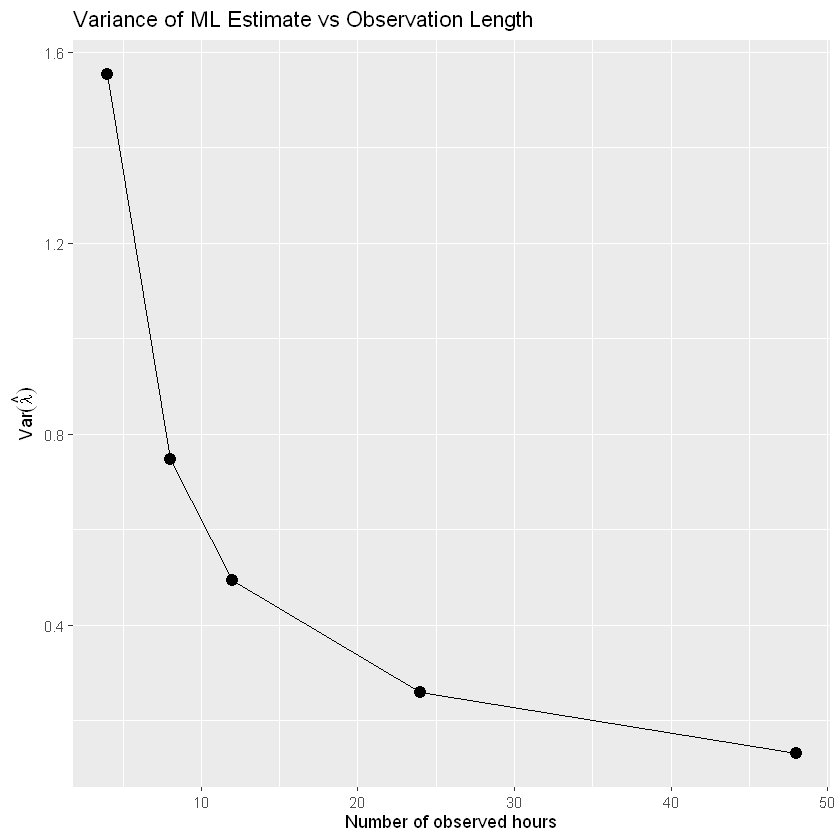

In [ ]:
# For each observation length, compute how variable the λ estimates are (variance or SD across the 1000 repeats).
# Plot the variance versus the number of observed hours, and describe the trend in one clear sentence.

lambda_true <- 6
B <- 1000
observation_lengths <- c(4, 8, 12, 24, 48)

variability <- data.frame()
for (n in observation_lengths) {
  lambda_hats <- replicate(B, {
    mean(rpois(n, lambda_true))
  })
  
  variability <- rbind(
    variability,
    data.frame(
      hours = n,
      variance = var(lambda_hats),
      sd = sd(lambda_hats)
    )
  )
}

ggplot(variability, aes(x = hours, y = variance)) +
  geom_line() +
  geom_point(size = 3) +
  labs(
    title = "Variance of ML Estimate vs Observation Length",
    x = "Number of observed hours",
    y = expression(Var(hat(lambda)))
  )


### Section 5: True vs Estimated distribution

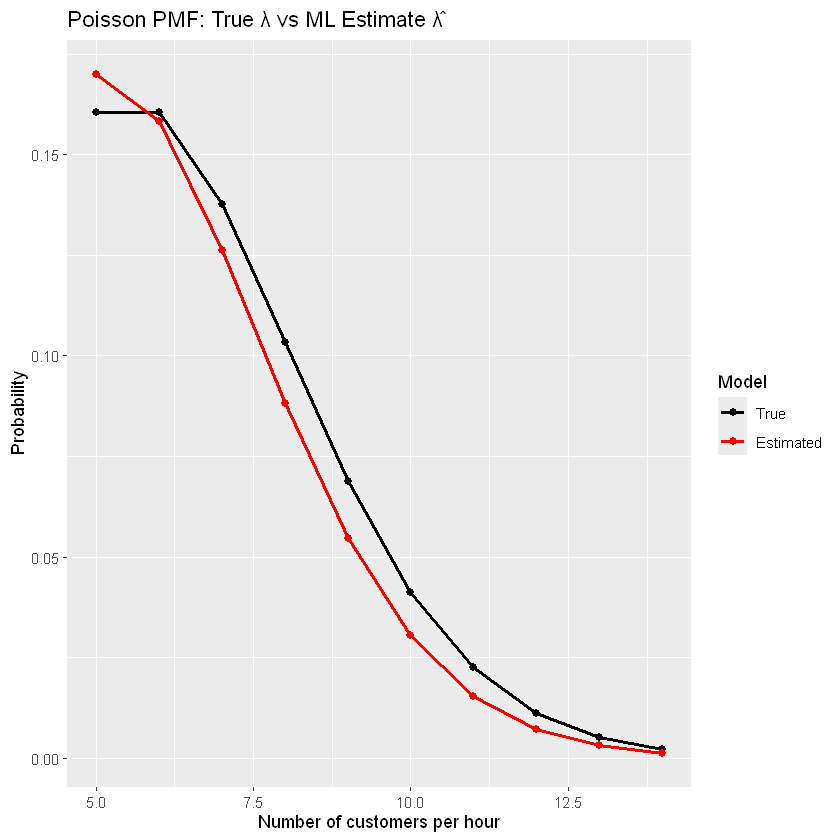

In [42]:
# Use the ML estimate of λ (λ̂ = the sample mean) and plot the Poisson PMF for:
# (1) the true λ and (2) the estimated λ̂ (MLE) on the same figure.

lambda_true <- 6
x_obs <- rpois(24, lambda_true)
lambda_hat <- mean(x_obs)

k <- 0:max(x_obs) + 5  

pmf_df <- data.frame(
  k = k,
  True = dpois(k, lambda_true),
  Estimated = dpois(k, lambda_hat)
)

pmf_long <- reshape2::melt(pmf_df, id.vars = "k",
                           variable.name = "Model",
                           value.name = "Probability")

ggplot(pmf_long, aes(x = k, y = Probability, color = Model)) +
  geom_line(linewidth = 1) +
  geom_point(size = 2) +
  labs(
    title = "Poisson PMF: True λ vs ML Estimate λ̂",
    x = "Number of customers per hour",
    y = "Probability"
  ) +
  scale_color_manual(values = c("True" = "black", "Estimated" = "red"))
